In [10]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [3]:
# 2 Load Dataset

df = pd.read_csv("Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:
# Dataset Overview

print("Dataset Shape:", df.shape)

print("\nDataset Info")
print(df.info())
df.shape

Dataset Shape: (9969, 21)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
Index: 9969 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9969 non-null   int64  
 1   Order ID       9969 non-null   object 
 2   Order Date     9969 non-null   object 
 3   Ship Date      9969 non-null   object 
 4   Ship Mode      9969 non-null   object 
 5   Customer ID    9969 non-null   object 
 6   Customer Name  9969 non-null   object 
 7   Segment        9969 non-null   object 
 8   Country        9969 non-null   object 
 9   City           9969 non-null   object 
 10  State          9969 non-null   object 
 11  Postal Code    9969 non-null   int64  
 12  Region         9969 non-null   object 
 13  Product ID     9969 non-null   object 
 14  Category       9969 non-null   object 
 15  Sub-Category   9969 non-null   object 
 16  Product Name   9969 non-null   object 
 17  Sales          99

(9969, 21)

In [ ]:
# Data Cleaning

df['Order Date'] = pd.to_datetime(df['Order Date'])

In [14]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [7]:
# Remove Duplicates

print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate Rows: 0


In [8]:
# 7 Remove Extreme Outliers

df = df[df['Sales'] < 5000]
df = df[df['Profit'] > -2000]

In [9]:
# Exploratory Data Analysis
# Basic Statistics


print(df[['Sales','Profit','Quantity','Discount']].describe())


             Sales       Profit     Quantity     Discount
count  9969.000000  9969.000000  9969.000000  9969.000000
mean    210.903499    26.173621     3.785535     0.155922
std     431.896397   137.890344     2.223729     0.206028
min       0.444000 -1862.312400     1.000000     0.000000
25%      17.220000     1.734300     2.000000     0.000000
50%      53.982000     8.639100     3.000000     0.200000
75%     208.160000    29.245000     5.000000     0.200000
max    4912.590000  2400.965700    14.000000     0.800000


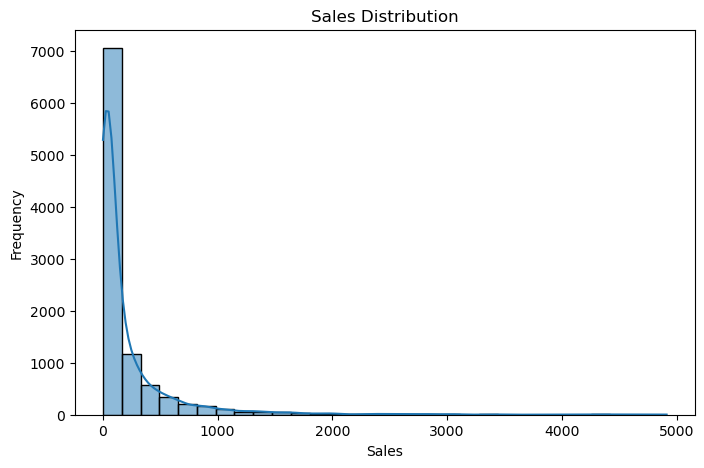

In [13]:
# Sales Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30, kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

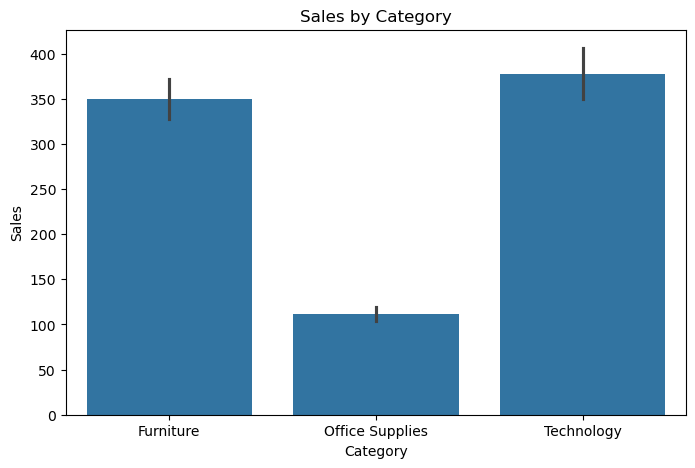

In [16]:
# Sales by Category

plt.figure(figsize=(8,5))

sns.barplot(x='Category', y='Sales', data=df)

plt.title("Sales by Category")

plt.show()

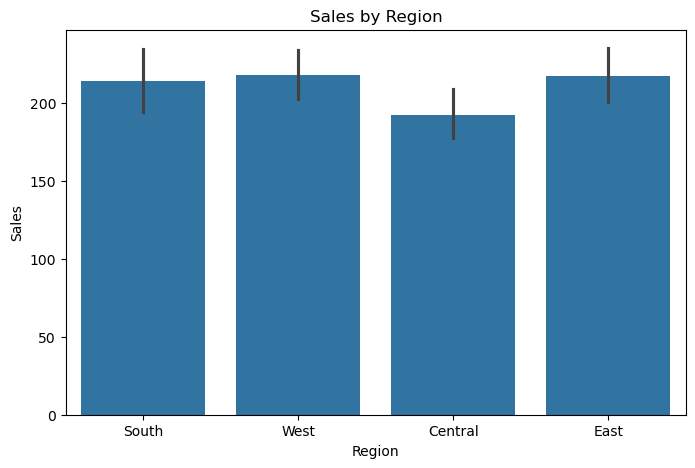

In [17]:
# Sales by Region

plt.figure(figsize=(8,5))

sns.barplot(x='Region', y='Sales', data=df)

plt.title("Sales by Region")

plt.show()

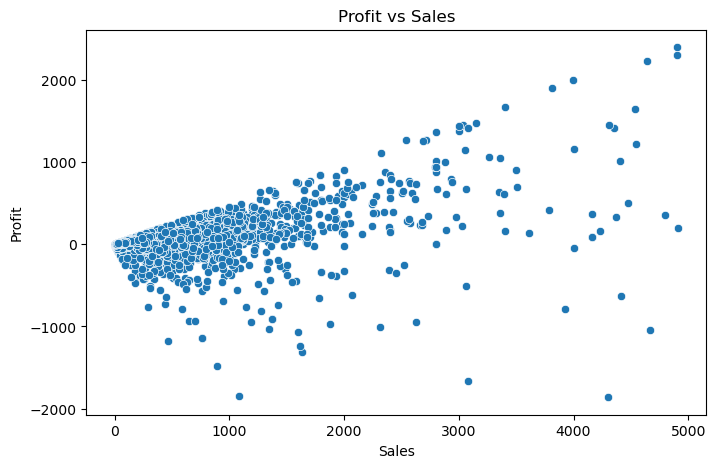

In [18]:
# Profit vs Sales

plt.figure(figsize=(8,5))

sns.scatterplot(x='Sales', y='Profit', data=df)

plt.title("Profit vs Sales")

plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

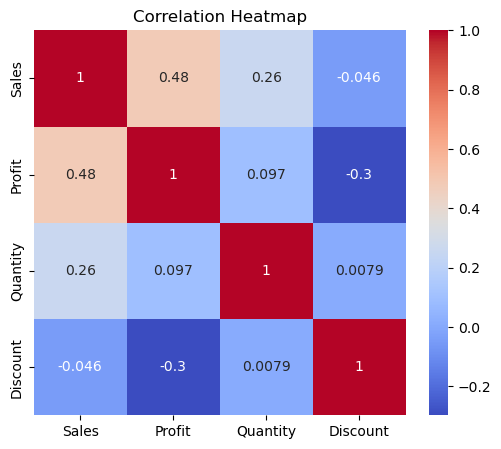

In [19]:
# Correlation Heatmap

plt.figure(figsize=(6,5))

sns.heatmap(df[['Sales','Profit','Quantity','Discount']].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")


In [20]:
# Feature Selection

data_ml = df[['Sales','Quantity','Discount','Profit','Category','Region','Segment']]


# 15 Convert Categorical Variables

data_ml = pd.get_dummies(data_ml, drop_first=True)

In [28]:
# Split Features and Target

X = data_ml.drop('Profit', axis=1)

y = data_ml['Profit']

In [27]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
# Train Random Forest Model

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [29]:
# Predictions

y_pred = model.predict(X_test)

In [30]:
# Model Evaluation

print("\nModel Performance")

print("MAE:", mean_absolute_error(y_test, y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))

print("R2 Score:", r2_score(y_test, y_pred))


Model Performance
MAE: 21.1709735779452
MSE: 5160.120537793613
R2 Score: 0.7691749597253863


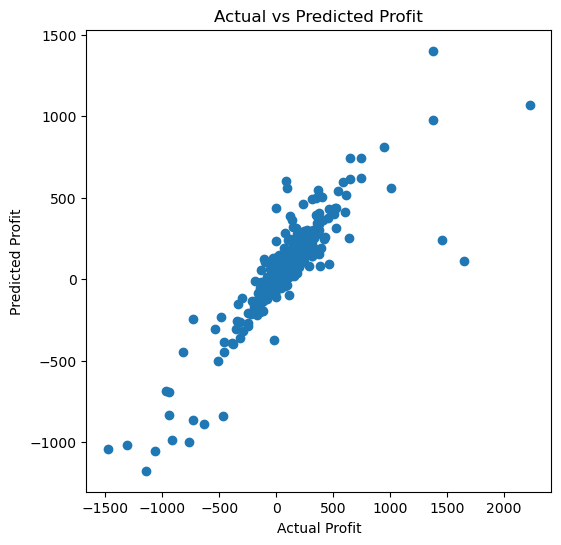

In [31]:
# Actual vs Predicted Scatter Plot

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")

plt.title("Actual vs Predicted Profit")

plt.show()

In [32]:
# Actual vs Predicted Table

results = pd.DataFrame({
    'Actual Profit': y_test,
    'Predicted Profit': y_pred
})

print("\nPrediction Sample")

print(results.head(10))


Prediction Sample
      Actual Profit  Predicted Profit
675         40.7499         29.752353
1883        78.6828         34.048018
9255         6.8724          6.953276
107          2.0994          4.381621
440          3.6660          4.666769
39         -15.1470        -36.722211
2501        -3.5712         -3.968509
9351       -20.7846        -15.347857
7016       164.6316        159.450928
4495        75.5937         33.526600


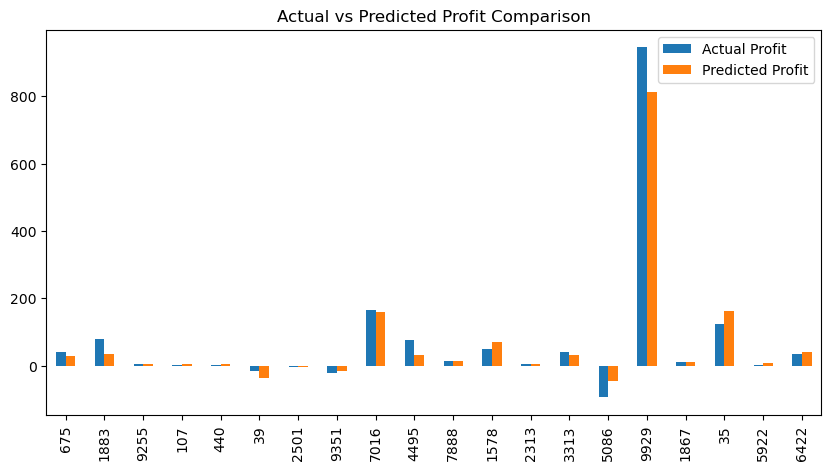

In [33]:
# Bar Chart Comparison

comparison = results.head(20)

comparison.plot(kind='bar', figsize=(10,5))

plt.title("Actual vs Predicted Profit Comparison")

plt.show()